# 04 Customer Analysis

This notebook analyzes customer behavior in the Online Retail dataset.

The goal is to understand:
- How many customers are in the dataset
- Which customers generate the most revenue
- Which customers place the most orders
- How frequently customers purchase
- How much customers spend on average

Rows without a CustomerID are excluded from customer-level analysis because they cannot be linked to a specific customer.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
file_path = r"C:/Users/IBRA/Desktop/online-retail-sales-analysis/data/cleaned/online_retail_cleaned.csv"

df = pd.read_csv(
    file_path,
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string",
        "CustomerID": "Int64"
    },
    parse_dates=["InvoiceDate"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,HasCustomerID,ProductDescription,TotalPrice,IsHighValueOutlier,IsNonProduct
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,True,WHITE HANGING HEART T-LIGHT HOLDER,15.30,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,WHITE METAL LANTERN,20.34,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,True,CREAM CUPID HEARTS COAT HANGER,22.00,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,KNITTED UNION FLAG HOT WATER BOTTLE,20.34,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,RED WOOLLY HOTTIE WHITE HEART.,20.34,False,False


In [15]:
customer_df = df[df["CustomerID"].notna()].copy()

print("Original dataset shape:", df.shape)
print("Customer dataset shape:", customer_df.shape)
print("Unique customers:", customer_df["CustomerID"].nunique())

Original dataset shape: (524878, 14)
Customer dataset shape: (392692, 14)
Unique customers: 4338


In [16]:
total_customers = customer_df["CustomerID"].nunique()
total_customer_revenue = customer_df["TotalPrice"].sum()
total_customer_invoices = customer_df["InvoiceNo"].nunique()
average_revenue_per_customer = total_customer_revenue / total_customers
average_invoices_per_customer = total_customer_invoices / total_customers

print("Total customers:", total_customers)
print("Total revenue from identified customers:", round(total_customer_revenue, 2))
print("Total invoices from identified customers:", total_customer_invoices)
print("Average revenue per customer:", round(average_revenue_per_customer, 2))
print("Average invoices per customer:", round(average_invoices_per_customer, 2))

Total customers: 4338
Total revenue from identified customers: 8887208.89
Total invoices from identified customers: 18532
Average revenue per customer: 2048.69
Average invoices per customer: 4.27


## Customer Analysis Overview

This section focuses only on transactions with a valid CustomerID.

The main customer-level KPIs are:
- Total number of identified customers
- Total revenue from identified customers
- Total number of invoices from identified customers
- Average revenue per customer
- Average number of invoices per customer

These metrics help us understand the overall customer base before analyzing individual customer behavior.

In [17]:
customer_summary = customer_df.groupby("CustomerID").agg(
    TotalRevenue=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    InvoiceCount=("InvoiceNo", "nunique"),
    FirstPurchaseDate=("InvoiceDate", "min"),
    LastPurchaseDate=("InvoiceDate", "max")
).reset_index()

customer_summary["AverageOrderValue"] = customer_summary["TotalRevenue"] / customer_summary["InvoiceCount"]

customer_summary.head()

,CustomerID,TotalRevenue,TotalQuantity,InvoiceCount,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue
0,12346,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000
1,12347,4310.00,2458,7,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286
2,12348,1797.24,2341,4,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000
3,12349,1757.55,631,1,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000
4,12350,334.40,197,1,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000


In [18]:
print("Customer summary shape:", customer_summary.shape)

customer_summary.describe()

Customer summary shape: (4338, 7)


,CustomerID,TotalRevenue,TotalQuantity,InvoiceCount,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue
count,4338.0,4338.000000,4338.000000,4338.000000,4338,4338,4338.000000
mean,15300.408022,2048.688081,1187.644537,4.272015,2011-04-30 17:06:50.857538048,2011-09-08 11:38:59.045643008,417.645735
min,12346.0,3.750000,1.000000,1.000000,2010-12-01 08:26:00,2010-12-01 09:53:00,3.450000
25%,13813.25,306.482500,159.000000,1.000000,2011-01-17 11:13:15,2011-07-20 19:18:00,177.867083
50%,15299.5,668.570000,378.000000,2.000000,2011-04-05 09:52:30,2011-10-20 10:40:30,291.940000
75%,16778.75,1660.597500,989.750000,5.000000,2011-08-19 10:11:30,2011-11-22 11:05:45,428.280625
max,18287.0,280206.020000,196915.000000,209.000000,2011-12-09 12:16:00,2011-12-09 12:50:00,84236.250000
std,1721.808492,8985.230220,5043.619654,7.697998,NaN,NaN,1796.511343


In [19]:
top_customers_revenue = customer_summary.sort_values(
    by="TotalRevenue",
    ascending=False
).head(10)

top_customers_revenue

,CustomerID,TotalRevenue,TotalQuantity,InvoiceCount,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue
1689,14646,280206.02,196915,73,2010-12-20 10:09:00,2011-12-08 12:12:00,3838.438630
4201,18102,259657.30,64124,60,2010-12-07 16:42:00,2011-12-09 11:50:00,4327.621667
3728,17450,194390.79,69973,46,2010-12-07 09:23:00,2011-12-01 13:29:00,4225.886739
3008,16446,168472.50,80997,2,2011-05-18 09:52:00,2011-12-09 09:15:00,84236.250000
1879,14911,143711.17,80240,201,2010-12-01 14:05:00,2011-12-08 15:54:00,714.980945
55,12415,124914.53,77374,21,2011-01-06 11:12:00,2011-11-15 14:22:00,5948.310952
1333,14156,117210.08,57768,55,2010-12-03 11:48:00,2011-11-30 10:54:00,2131.092364
3771,17511,91062.38,64549,31,2010-12-01 10:19:00,2011-12-07 10:12:00,2937.496129
2702,16029,80850.84,40108,63,2010-12-01 09:57:00,2011-11-01 10:27:00,1283.346667
0,12346,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000


## Customer Summary Table

A customer-level summary table was created by grouping the dataset by CustomerID.

For each customer, the following metrics were calculated:
- TotalRevenue: total amount spent by the customer
- TotalQuantity: total number of items purchased
- InvoiceCount: number of unique invoices/orders
- FirstPurchaseDate: first recorded purchase date
- LastPurchaseDate: most recent recorded purchase date
- AverageOrderValue: average revenue per invoice

This table allows customer behavior to be analyzed at the customer level instead of the transaction level.

In [20]:
top_customers_orders = customer_summary.sort_values(
    by="InvoiceCount",
    ascending=False
).head(10)

top_customers_orders

,CustomerID,TotalRevenue,TotalQuantity,InvoiceCount,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue
326,12748,33053.19,25287,209,2010-12-01 12:48:00,2011-12-09 12:20:00,158.149234
1879,14911,143711.17,80240,201,2010-12-01 14:05:00,2011-12-08 15:54:00,714.980945
4010,17841,40519.84,22834,124,2010-12-01 14:41:00,2011-12-08 12:07:00,326.772903
562,13089,58762.08,31025,97,2010-12-05 10:27:00,2011-12-07 09:02:00,605.794639
1661,14606,12076.15,6187,93,2010-12-01 16:57:00,2011-12-08 19:28:00,129.851075
2176,15311,60632.75,38147,91,2010-12-01 09:41:00,2011-12-09 12:00:00,666.293956
481,12971,11189.91,9289,86,2010-12-02 16:42:00,2011-12-06 12:20:00,130.115233
1689,14646,280206.02,196915,73,2010-12-20 10:09:00,2011-12-08 12:12:00,3838.438630
2702,16029,80850.84,40108,63,2010-12-01 09:57:00,2011-11-01 10:27:00,1283.346667
795,13408,28117.04,16232,62,2010-12-01 10:39:00,2011-12-08 09:05:00,453.500645


In [21]:
top_customers_quantity = customer_summary.sort_values(
    by="TotalQuantity",
    ascending=False
).head(10)

top_customers_quantity

,CustomerID,TotalRevenue,TotalQuantity,InvoiceCount,FirstPurchaseDate,LastPurchaseDate,AverageOrderValue
1689,14646,280206.02,196915,73,2010-12-20 10:09:00,2011-12-08 12:12:00,3838.438630
3008,16446,168472.50,80997,2,2011-05-18 09:52:00,2011-12-09 09:15:00,84236.250000
1879,14911,143711.17,80240,201,2010-12-01 14:05:00,2011-12-08 15:54:00,714.980945
55,12415,124914.53,77374,21,2011-01-06 11:12:00,2011-11-15 14:22:00,5948.310952
0,12346,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000
3728,17450,194390.79,69973,46,2010-12-07 09:23:00,2011-12-01 13:29:00,4225.886739
3771,17511,91062.38,64549,31,2010-12-01 10:19:00,2011-12-07 10:12:00,2937.496129
4201,18102,259657.30,64124,60,2010-12-07 16:42:00,2011-12-09 11:50:00,4327.621667
996,13694,65039.62,63312,50,2010-12-01 12:12:00,2011-12-06 09:32:00,1300.792400
1434,14298,51527.30,58343,44,2010-12-14 12:59:00,2011-12-01 13:12:00,1171.075000


In [22]:
customer_summary["TotalRevenue"].describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: TotalRevenue, dtype: float64

## Top Customer Insights

The top customers by revenue show that a small number of customers contribute a very large share of total revenue.

However, revenue alone does not fully explain customer behavior. Some customers have very high revenue because of one or two large orders, while others generate revenue through repeated purchases.

To better understand customer value, this analysis compares customers by:
- Total revenue
- Number of invoices/orders
- Total quantity purchased
- Average order value

This helps separate frequent repeat customers from occasional bulk buyers.

In [23]:
total_revenue = customer_summary["TotalRevenue"].sum()

top_10_revenue = customer_summary.sort_values(
    by="TotalRevenue",
    ascending=False
).head(10)["TotalRevenue"].sum()

top_20_revenue = customer_summary.sort_values(
    by="TotalRevenue",
    ascending=False
).head(20)["TotalRevenue"].sum()

top_50_revenue = customer_summary.sort_values(
    by="TotalRevenue",
    ascending=False
).head(50)["TotalRevenue"].sum()

print("Top 10 customers revenue share:", round((top_10_revenue / total_revenue) * 100, 2), "%")
print("Top 20 customers revenue share:", round((top_20_revenue / total_revenue) * 100, 2), "%")
print("Top 50 customers revenue share:", round((top_50_revenue / total_revenue) * 100, 2), "%")

Top 10 customers revenue share: 17.3 %
Top 20 customers revenue share: 23.91 %
Top 50 customers revenue share: 33.3 %


In [24]:
customer_summary["CustomerType"] = np.where(
    customer_summary["InvoiceCount"] == 1,
    "One-time customer",
    "Repeat customer"
)

customer_type_summary = customer_summary.groupby("CustomerType").agg(
    CustomerCount=("CustomerID", "count"),
    TotalRevenue=("TotalRevenue", "sum"),
    AverageRevenue=("TotalRevenue", "mean"),
    AverageInvoices=("InvoiceCount", "mean")
).reset_index()

customer_type_summary["RevenueShare"] = (
    customer_type_summary["TotalRevenue"] / customer_summary["TotalRevenue"].sum()
) * 100

customer_type_summary

,CustomerType,CustomerCount,TotalRevenue,AverageRevenue,AverageInvoices,RevenueShare
0,One-time customer,1493,613989.561,411.245520,1.000000,6.908688
1,Repeat customer,2845,8273219.333,2907.985706,5.989104,93.091312


In [25]:
customer_summary["InvoiceCount"].describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceCount, dtype: float64

## Customer Revenue Concentration and Repeat Behavior

Customer spending is highly concentrated. A small number of customers generate a large share of total revenue, while most customers spend much less.

The analysis also separates customers into:
- One-time customers: customers with only one invoice
- Repeat customers: customers with more than one invoice

This helps identify whether revenue is mainly driven by loyal repeat customers or by occasional large bulk purchases.

In [26]:
customer_summary["CustomerLifetimeDays"] = (
    customer_summary["LastPurchaseDate"] - customer_summary["FirstPurchaseDate"]
).dt.days

customer_summary[[
    "CustomerID",
    "FirstPurchaseDate",
    "LastPurchaseDate",
    "CustomerLifetimeDays",
    "InvoiceCount",
    "TotalRevenue"
]].head()

,CustomerID,FirstPurchaseDate,LastPurchaseDate,CustomerLifetimeDays,InvoiceCount,TotalRevenue
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,0,1,77183.60
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,365,7,4310.00
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,282,4,1797.24
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,0,1,1757.55
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1,334.40


In [27]:
customer_summary["CustomerLifetimeDays"].describe()

count    4338.000000
mean      130.448594
std       132.039554
min         0.000000
25%         0.000000
50%        92.500000
75%       251.750000
max       373.000000
Name: CustomerLifetimeDays, dtype: float64

In [28]:
customer_country = customer_df.groupby("CustomerID").agg(
    Country=("Country", lambda x: x.mode()[0]),
    TotalRevenue=("TotalPrice", "sum"),
    InvoiceCount=("InvoiceNo", "nunique")
).reset_index()

customer_country_summary = customer_country.groupby("Country").agg(
    CustomerCount=("CustomerID", "count"),
    TotalRevenue=("TotalRevenue", "sum"),
    AverageRevenuePerCustomer=("TotalRevenue", "mean"),
    AverageInvoicesPerCustomer=("InvoiceCount", "mean")
).reset_index()

customer_country_summary = customer_country_summary.sort_values(
    by="CustomerCount",
    ascending=False
)

customer_country_summary.head(10)

,Country,CustomerCount,TotalRevenue,AverageRevenuePerCustomer,AverageInvoicesPerCustomer
35,United Kingdom,3920,7285024.644,1858.424654,4.246429
14,Germany,94,228678.400,2432.748936,4.861702
13,France,87,208934.310,2401.543793,4.471264
30,Spain,29,62821.160,2166.246897,3.137931
3,Belgium,24,41551.260,1731.302500,4.083333
32,Switzerland,20,56419.290,2820.964500,2.600000
26,Portugal,19,33375.840,1756.623158,3.000000
18,Italy,14,17483.240,1248.802857,2.714286
12,Finland,12,22546.080,1878.840000,3.416667
24,Norway,10,36165.440,3616.544000,3.600000


In [29]:
customer_country["Market"] = np.where(
    customer_country["Country"] == "United Kingdom",
    "United Kingdom",
    "Non-UK"
)

market_customer_summary = customer_country.groupby("Market").agg(
    CustomerCount=("CustomerID", "count"),
    TotalRevenue=("TotalRevenue", "sum"),
    AverageRevenuePerCustomer=("TotalRevenue", "mean"),
    AverageInvoicesPerCustomer=("InvoiceCount", "mean")
).reset_index()

market_customer_summary["CustomerShare"] = (
    market_customer_summary["CustomerCount"] / market_customer_summary["CustomerCount"].sum()
) * 100

market_customer_summary["RevenueShare"] = (
    market_customer_summary["TotalRevenue"] / market_customer_summary["TotalRevenue"].sum()
) * 100

market_customer_summary

,Market,CustomerCount,TotalRevenue,AverageRevenuePerCustomer,AverageInvoicesPerCustomer,CustomerShare,RevenueShare
0,Non-UK,418,1602184.250,3832.976675,4.511962,9.635777,18.02798
1,United Kingdom,3920,7285024.644,1858.424654,4.246429,90.364223,81.97202


## Customer Location Analysis

Customer behavior was also analyzed by country.

Since the United Kingdom dominates the dataset, customers were grouped into:
- United Kingdom customers
- Non-UK customers

This helps compare the size and revenue contribution of the domestic customer base against international customers.

## Customer Country Insights

The United Kingdom has the largest customer base, with 3,920 customers, representing about 90.36% of identified customers.

However, non-UK customers have a higher average revenue per customer:
- UK average revenue per customer: 1,858.42
- Non-UK average revenue per customer: 3,832.98

This means the UK dominates by customer count and total revenue, but international customers appear more valuable on average.

This supports the earlier EDA decision to separate UK and non-UK analysis because UK dominance can hide important international patterns.

In [30]:
snapshot_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = customer_summary[[
    "CustomerID",
    "TotalRevenue",
    "InvoiceCount",
    "LastPurchaseDate"
]].copy()

rfm["Recency"] = (snapshot_date - rfm["LastPurchaseDate"]).dt.days
rfm["Frequency"] = rfm["InvoiceCount"]
rfm["Monetary"] = rfm["TotalRevenue"]

rfm = rfm[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [31]:
snapshot_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = customer_summary[[
    "CustomerID",
    "TotalRevenue",
    "InvoiceCount",
    "LastPurchaseDate"
]].copy()

rfm["Recency"] = (snapshot_date - rfm["LastPurchaseDate"]).dt.days
rfm["Frequency"] = rfm["InvoiceCount"]
rfm["Monetary"] = rfm["TotalRevenue"]

rfm = rfm[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [32]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.0,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.0,1.000000,1.000000,3.750000
25%,13813.25,18.000000,1.000000,306.482500
50%,15299.5,51.000000,2.000000,668.570000
75%,16778.75,142.000000,5.000000,1660.597500
max,18287.0,374.000000,209.000000,280206.020000


In [33]:
rfm["RScore"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["FScore"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["MScore"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFMScore"] = rfm["RScore"] + rfm["FScore"] + rfm["MScore"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMScore
0,12346,326,1,77183.60,1,1,5,7
1,12347,2,7,4310.00,5,5,5,15
2,12348,75,4,1797.24,2,4,4,10
3,12349,19,1,1757.55,4,1,4,9
4,12350,310,1,334.40,1,1,2,4


In [34]:
rfm[["RScore", "FScore", "MScore", "RFMScore"]].describe()

,RScore,FScore,MScore,RFMScore
count,4338.00000,4338.00000,4338.00000,4338.000000
mean,3.00000,3.00000,3.00000,9.000000
std,1.41454,1.41454,1.41454,3.589625
min,1.00000,1.00000,1.00000,3.000000
25%,2.00000,2.00000,2.00000,6.000000
50%,3.00000,3.00000,3.00000,9.000000
75%,4.00000,4.00000,4.00000,12.000000
max,5.00000,5.00000,5.00000,15.000000


In [35]:
def segment_customer(row):
    if row["RFMScore"] >= 13:
        return "Best Customers"
    elif row["RScore"] >= 4 and row["FScore"] >= 4:
        return "Loyal Customers"
    elif row["RScore"] >= 4 and row["FScore"] <= 2:
        return "New or Recent Customers"
    elif row["RScore"] <= 2 and row["FScore"] >= 4:
        return "At Risk Customers"
    elif row["RScore"] <= 2 and row["MScore"] >= 4:
        return "Past High-Value Customers"
    elif row["RFMScore"] <= 5:
        return "Low Value Customers"
    else:
        return "Regular Customers"

rfm["CustomerSegment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMScore,CustomerSegment
0,12346,326,1,77183.60,1,1,5,7,Past High-Value Customers
1,12347,2,7,4310.00,5,5,5,15,Best Customers
2,12348,75,4,1797.24,2,4,4,10,At Risk Customers
3,12349,19,1,1757.55,4,1,4,9,New or Recent Customers
4,12350,310,1,334.40,1,1,2,4,Low Value Customers


In [36]:
segment_summary = rfm.groupby("CustomerSegment").agg(
    CustomerCount=("CustomerID", "count"),
    AverageRecency=("Recency", "mean"),
    AverageFrequency=("Frequency", "mean"),
    AverageMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum")
).reset_index()

segment_summary["CustomerShare"] = (
    segment_summary["CustomerCount"] / segment_summary["CustomerCount"].sum()
) * 100

segment_summary["RevenueShare"] = (
    segment_summary["TotalRevenue"] / segment_summary["TotalRevenue"].sum()
) * 100

segment_summary = segment_summary.sort_values(
    by="TotalRevenue",
    ascending=False
)

segment_summary

,CustomerSegment,CustomerCount,AverageRecency,AverageFrequency,AverageMonetary,TotalRevenue,CustomerShare,RevenueShare
1,Best Customers,929,14.518837,11.779333,6705.386911,6229304.440,21.415399,70.092922
6,Regular Customers,1476,76.591463,2.316396,765.407163,1129740.973,34.024896,12.711989
5,Past High-Value Customers,171,160.970760,1.976608,2696.995795,461186.281,3.941909,5.189326
0,At Risk Customers,285,134.792982,4.887719,1590.721754,453355.700,6.569848,5.101216
3,Loyal Customers,282,18.148936,4.000000,955.051560,269324.540,6.500692,3.030474
2,Low Value Customers,885,223.972881,1.045198,228.313582,202057.520,20.401107,2.273577
4,New or Recent Customers,310,18.096774,1.245161,458.836903,142239.440,7.14615,1.600496


In [37]:
rfm["CustomerSegment"].value_counts()

CustomerSegment
Regular Customers            1476
Best Customers                929
Low Value Customers           885
New or Recent Customers       310
At Risk Customers             285
Loyal Customers               282
Past High-Value Customers     171
Name: count, dtype: int64

In [38]:
rfm.sort_values(
    by="RFMScore",
    ascending=False
).head(20)

,CustomerID,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMScore,CustomerSegment
2785,16143,3,6,2424.94,5,5,5,15,Best Customers
3381,16954,1,9,2085.08,5,5,5,15,Best Customers
445,12921,9,37,16587.09,5,5,5,15,Best Customers
4074,17924,12,7,2962.50,5,5,5,15,Best Customers
1063,13784,10,11,2462.79,5,5,5,15,Best Customers
1069,13798,1,57,37153.85,5,5,5,15,Best Customers
1739,14713,9,11,2662.20,5,5,5,15,Best Customers
431,12901,9,28,17654.54,5,5,5,15,Best Customers
1737,14711,10,11,2839.62,5,5,5,15,Best Customers
3018,16458,3,18,3482.74,5,5,5,15,Best Customers


## RFM Customer Segmentation

Customers were segmented using RFM analysis:

- Recency: how recently the customer purchased
- Frequency: how often the customer purchased
- Monetary: how much the customer spent

Each customer received a score from 1 to 5 for Recency, Frequency, and Monetary. These scores were combined into an overall RFM score.

The customer segments help identify:
- Best customers
- Loyal customers
- New or recent customers
- At-risk customers
- Past high-value customers
- Low-value customers
- Regular customers

This segmentation is useful because it turns raw customer metrics into business-friendly customer groups.

## RFM Segment Insights

The RFM segmentation shows that customer value is highly concentrated.

The most important segment is Best Customers:
- They represent about 21.42% of identified customers
- They generate about 70.09% of customer revenue
- They purchase recently, buy frequently, and spend the most on average

This suggests that the business depends heavily on a relatively small group of high-value customers.

Low Value Customers represent about 20.40% of customers but only generate about 2.27% of revenue. These customers are less recent, purchase rarely, and spend less.

Past High-Value Customers and At Risk Customers are also important because they previously generated meaningful revenue but may need re-engagement.

Overall, the business should focus on:
- Retaining Best Customers
- Re-engaging At Risk Customers
- Encouraging New or Recent Customers to make repeat purchases
- Investigating Past High-Value Customers for possible win-back campaigns

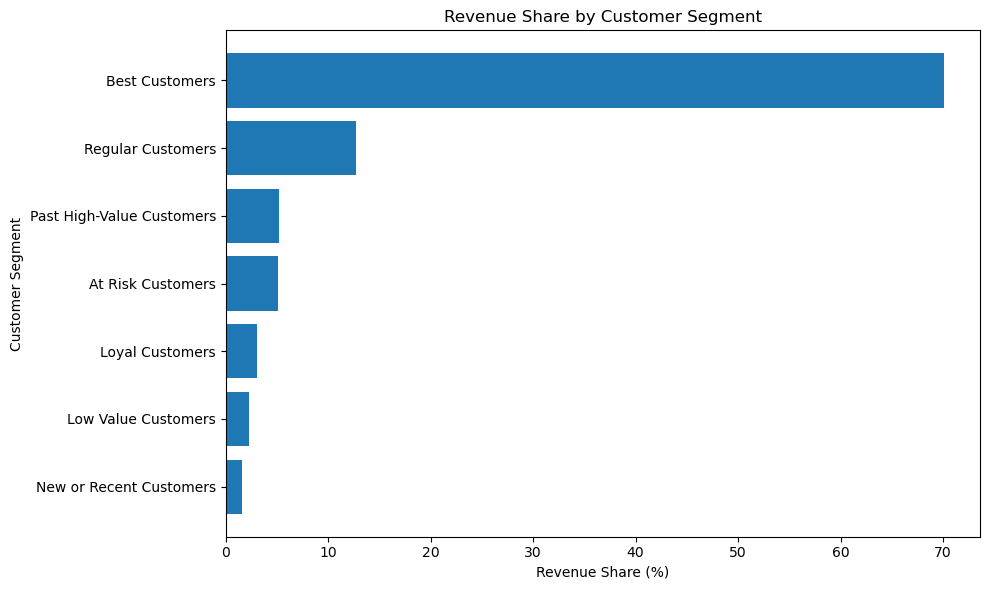

In [39]:
segment_summary_sorted = segment_summary.sort_values(
    by="RevenueShare",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(segment_summary_sorted["CustomerSegment"], segment_summary_sorted["RevenueShare"])
plt.title("Revenue Share by Customer Segment")
plt.xlabel("Revenue Share (%)")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

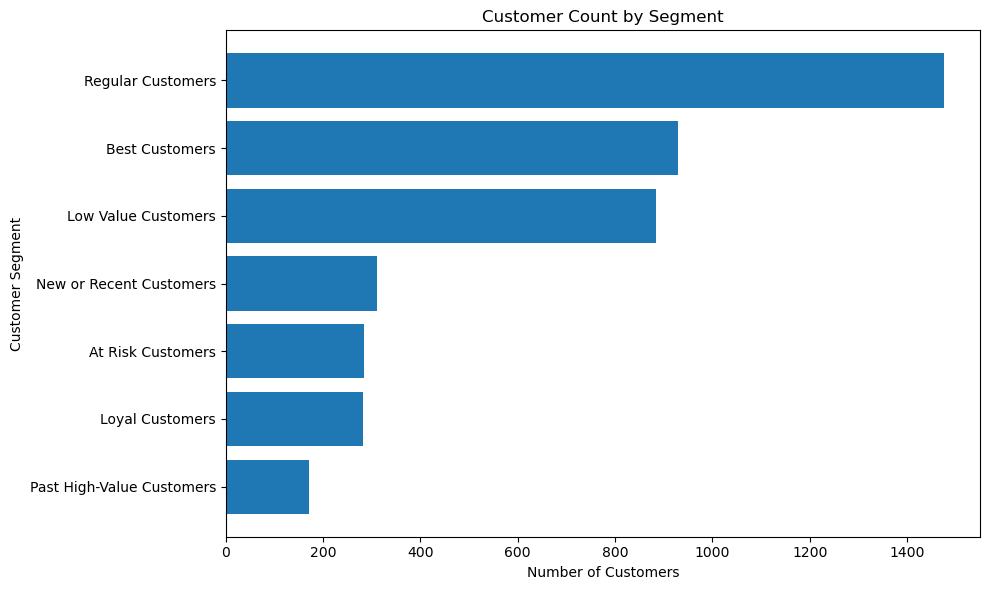

In [40]:
segment_count_sorted = segment_summary.sort_values(
    by="CustomerCount",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(segment_count_sorted["CustomerSegment"], segment_count_sorted["CustomerCount"])
plt.title("Customer Count by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

In [41]:
customer_summary.to_csv("../reports/customer_summary.csv", index=False)
rfm.to_csv("../reports/rfm_customer_segments.csv", index=False)
segment_summary.to_csv("../reports/customer_segment_summary.csv", index=False)

print("Customer analysis tables exported successfully.")

Customer analysis tables exported successfully.


In [1]:
from pathlib import Path

reports_path = Path("../reports")
reports_path.mkdir(exist_ok=True)

customer_summary.to_csv(reports_path / "customer_summary.csv", index=False)
rfm.to_csv(reports_path / "rfm_customer_segments.csv", index=False)
segment_summary.to_csv(reports_path / "customer_segment_summary.csv", index=False)

print("Customer analysis tables exported successfully.")

NameError: name 'customer_summary' is not defined